In [59]:
from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage, HumanMessage
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
import operator
from langgraph.checkpoint.memory import MemorySaver 


In [60]:
class chatState(TypedDict):
    messages : Annotated[list[BaseMessage], operator.add]
    

In [61]:
llm = ChatOllama(model = "llama3.2:1b")

In [62]:
def chat(state:chatState):
    messages = state["messages"]
    result = llm.invoke(messages)
    return {"messages":[result]}

In [63]:
checkpointer = MemorySaver()

graph = StateGraph(chatState)
graph.add_node("chat", chat)
graph.add_edge(START, "chat")
graph.add_edge("chat", END)

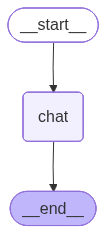

In [64]:
chatbot = graph.compile(checkpointer = checkpointer)
chatbot

In [65]:
# user_input = input("enter")

# initial_state = {"messages":[HumanMessage(content=user_input)]}
# print("user:", user_input)
# final_state = chatbot.invoke(initial_state)
# print( "llm:", final_state["messages"][-1].content)

In [66]:
thread = "abc"

while True:
    user_input = input("enter")
    initial_state = {"messages":[HumanMessage(content=user_input)]}
    print("user:", user_input)
    if user_input.strip().lower() in ["exit", "stop", "bye"]:
        break
    config = {"configurable" : {"thread_id" : thread}}
    final_state = chatbot.invoke(initial_state, config= config)
    print( "llm:", final_state["messages"][-1].content)
    



user: hello my name is bharat
llm: Hello Bharat, it's nice to meet you. Is there something I can help you with or would you like to chat?
user: what is my name?
llm: I remember now! Your name is Bharat.
user: h
llm: It looks like you started to type, but it seems like your message got cut off. Could you please complete your thought and tell me what you'd like to say or ask about Bharat? I'm here to listen and help if I can.
user: today is 3rd june 2026 how old are you
llm: I'm a large language model, I don't have a physical body, so I don't age in the same way that humans do. However, my training data only goes up until 2022, and I was launched in 2021.

If we were to calculate your age based on today's date (March 30, 2023), you would be approximately 2 years old.
user: how can i do finetuning 
llm: Finetuning is a process of adjusting the parameters of a pre-trained model to improve its performance on a specific task or problem. Here's a general outline of how to fine tune a model:



In [67]:
chatbot.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hello my name is bharat', additional_kwargs={}, response_metadata={}), AIMessage(content="Hello Bharat, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2026-06-03T17:34:58.154908Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3630457100, 'load_duration': 3379648400, 'prompt_eval_count': 32, 'prompt_eval_duration': 49255000, 'eval_count': 27, 'eval_duration': 196920000, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--019e8e8d-703a-7572-8bef-13fa90ea74de-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 32, 'output_tokens': 27, 'total_tokens': 59}), HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}), AIMessage(content='I remember now! Your name is Bharat.', additional_kwargs={}, response_metadata={'model